In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [5]:
# Let's load our dataset
df = pd.read_csv('C:/Users/HP/OneDrive/7CS030/Assessment/houseprice_data.csv')

In [6]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [13]:
# Let's separate features and target variables
X = df.drop(columns=['lat', 'long', 'price', 'zipcode'])
y = df['price']

In [14]:
# Next we split our data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Let's create a simple Linear Regression model using sqft_living
lr_sqft = LinearRegression().fit(X_train[['sqft_living']], y_train)
y_pred_sqft = lr_sqft.predict(X_test[['sqft_living']])
r2_sqft = r2_score(y_test, y_pred_sqft)

In [16]:
print("R^2 (sqft_living only):", r2_sqft)

R^2 (sqft_living only): 0.4941006145983624


In [17]:
# Now we create a Multiple Linear Regression with all features
lr_all = LinearRegression().fit(X_train, y_train)
y_pred_all = lr_all.predict(X_test)
r2_all = r2_score(y_test, y_pred_all)

In [18]:
print("R^2 (all features):", r2_all)

R^2 (all features): 0.6541412262064872


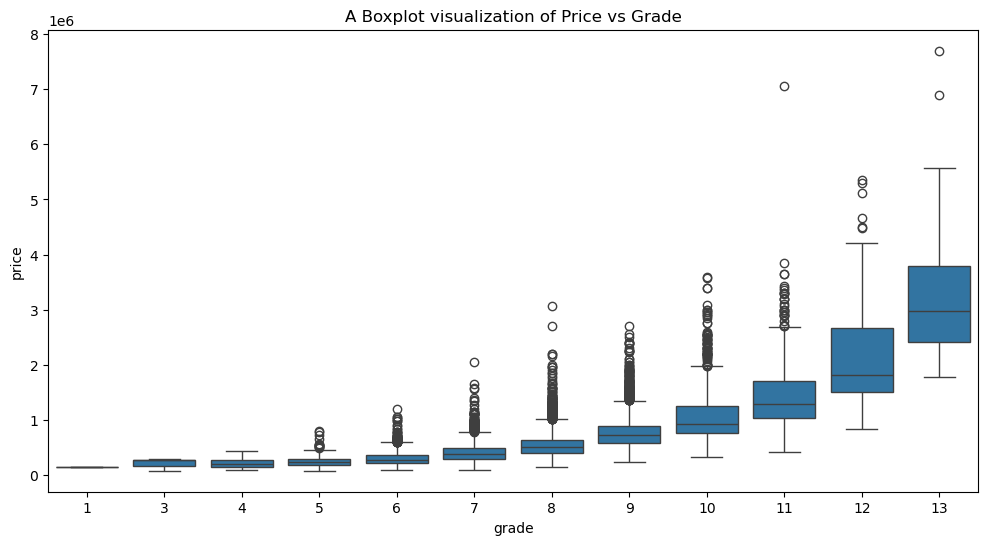

In [45]:
# ### DATA VISUALIZATION AND ANALYSIS
# Price Distribution
# Let's create a boxplot, scatterplot, histogram and Correlation heatmap of the price to visualize its distribution and outliers

# Boxplot: Price by Grade
# This is to visualize the price distribution across various house grades
plt.figure(figsize=(12,6))
sns.boxplot(x=df['grade'], y=df['price'])
plt.title("A Boxplot visualization of Price vs Grade")
plt.show()

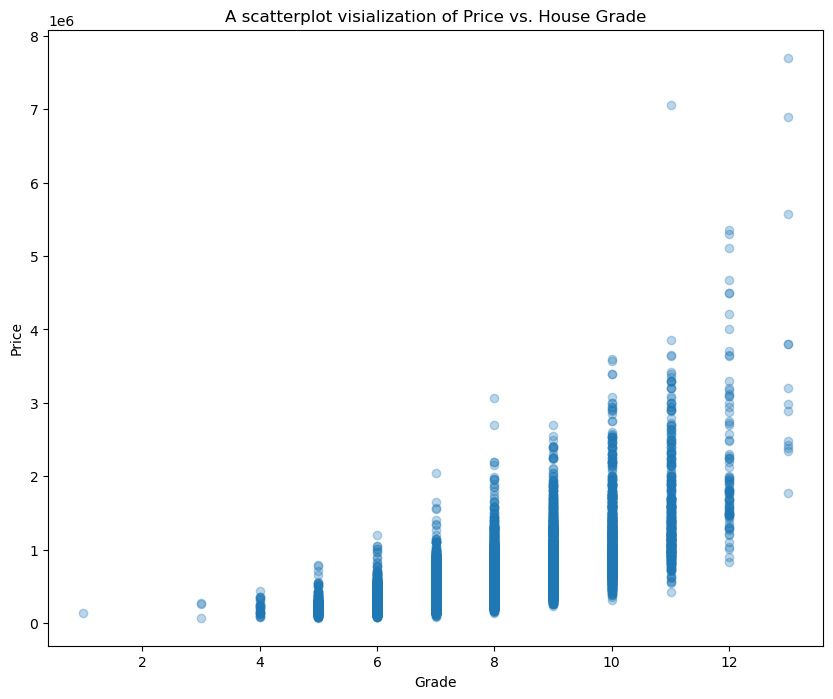

In [53]:
# Scatterplot Price vs Grade
# This visualization displays the correlation between thr price and house grade
plt.figure(figsize=(10,8))
plt.scatter(df['grade'], df['price'], alpha=0.3)
plt.xlabel('Grade')
plt.ylabel('Price')
plt.title('A scatterplot visialization of Price vs. House Grade')
plt.show()

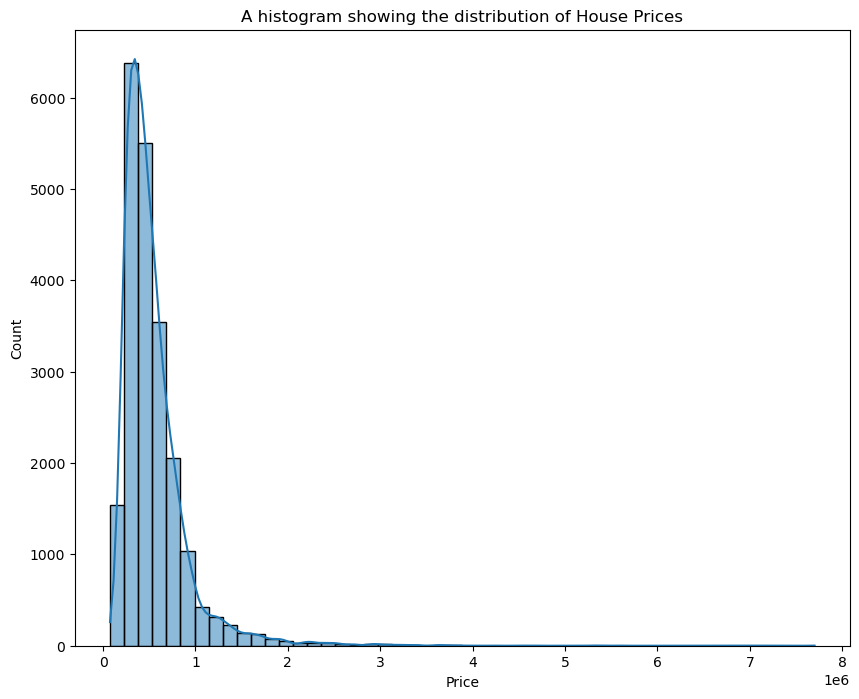

In [54]:
# Histogram
# This identifies outliers through the visualization of the target variable
plt.figure(figsize=(10,8))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('A histogram showing the distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

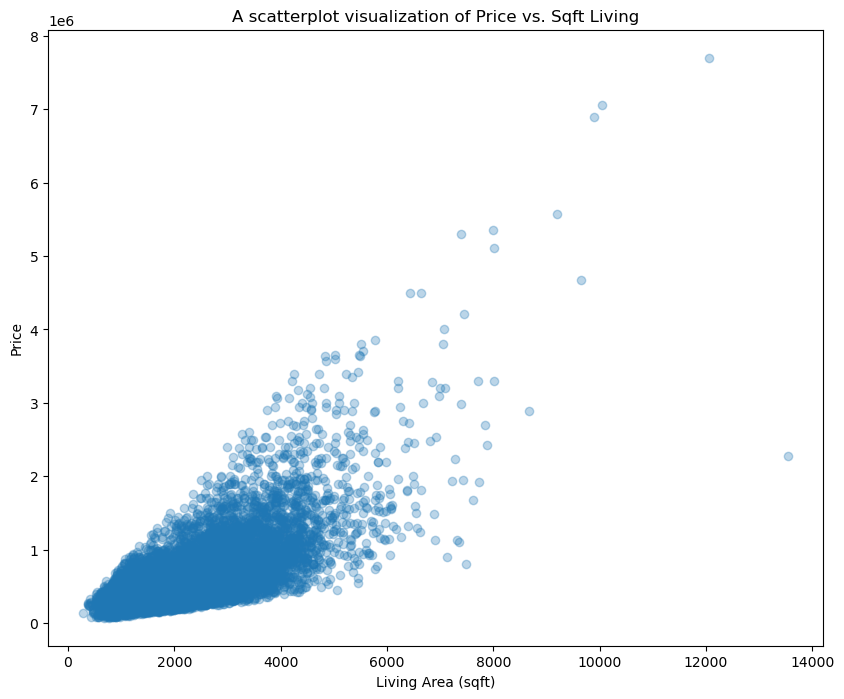

In [55]:
# Scatterplot
# This visualization displays the linear trend between home size and price
plt.figure(figsize=(10,8))
plt.scatter(df['sqft_living'], df['price'], alpha=0.3)
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.title('A scatterplot visualization of Price vs. Sqft Living')
plt.show()

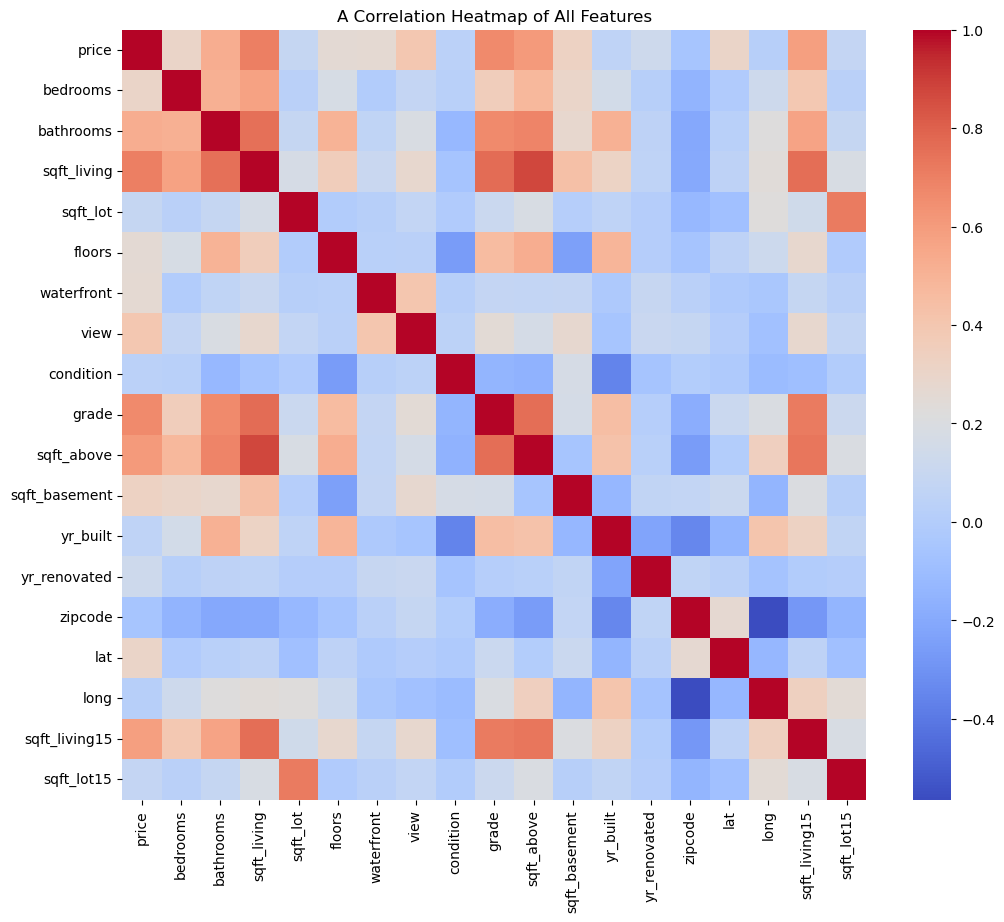

In [57]:
# Correlation Heatmap
# This visualization displays the correlation between all features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("A Correlation Heatmap of All Features")
plt.show()

In [40]:
# Time to Visualize predictions

y_pred_train = lr_all.predict(X_train)
residuals = y_train - y_pred_train

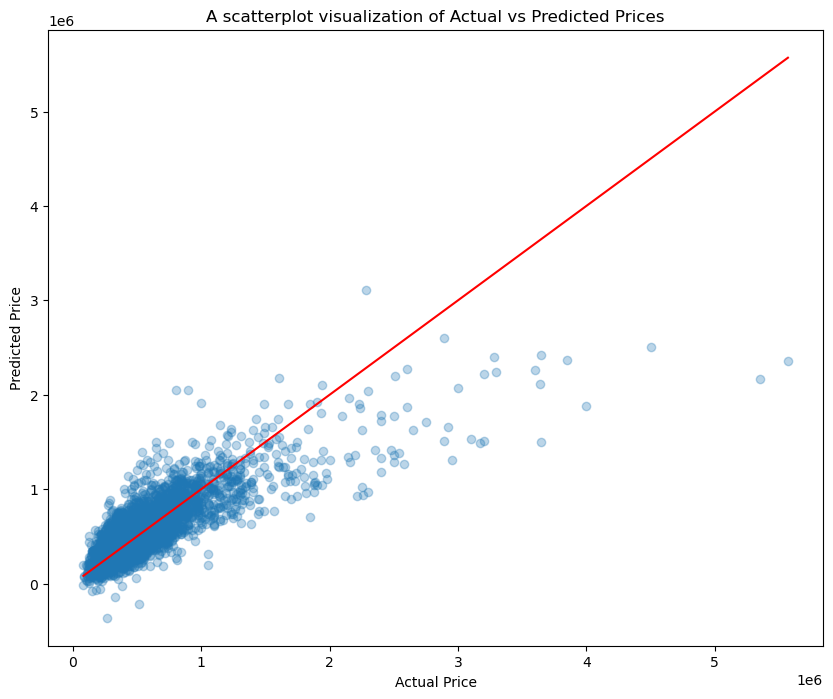

In [56]:
# Let's visualize the Actual vs Predicted Prices
# This scatterplot displays close predictions to real prices
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred_all, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("A scatterplot visualization of Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-')
plt.show()

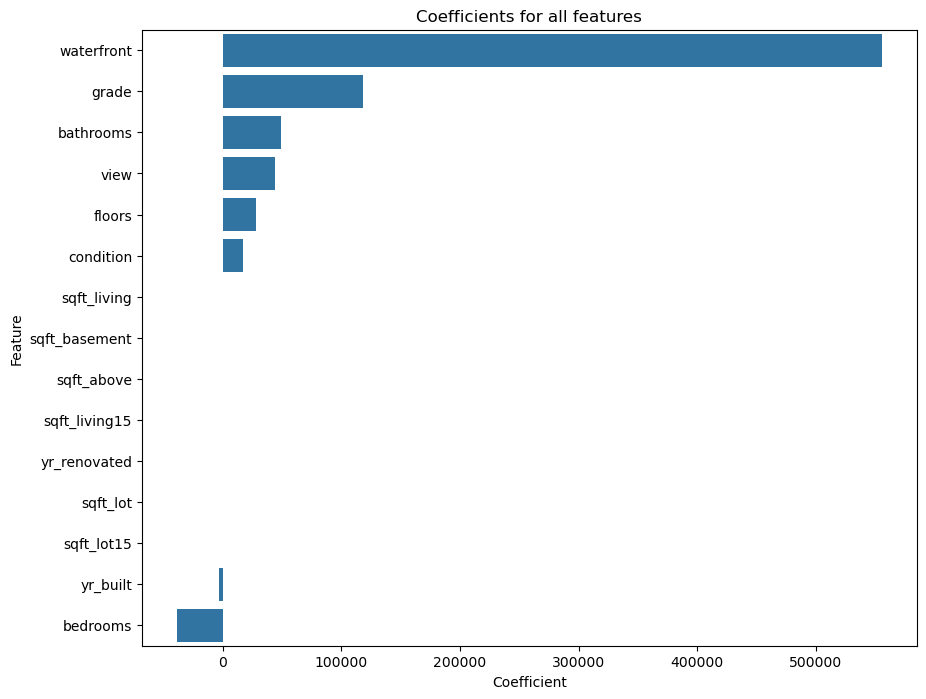

In [58]:
# Coefficient for features
# This visualization displays the most important features according to the influence on price
coef_df = pd.DataFrame({
'Feature': X_train.columns,
'Coefficient': lr_all.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title("Coefficients for all features")
plt.show()

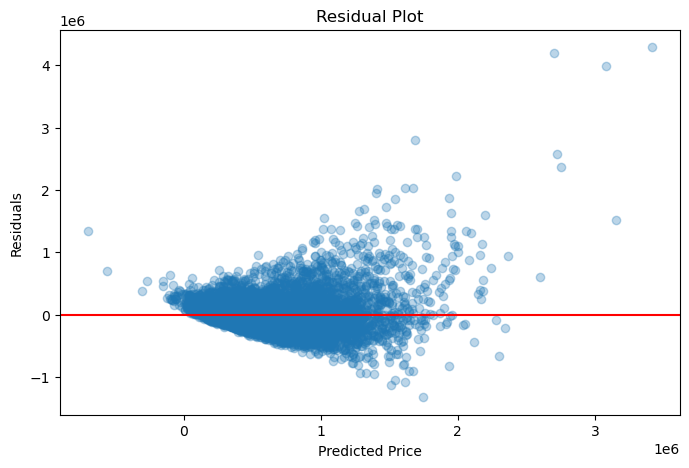

In [59]:
# Residual Plot
plt.figure(figsize=(8,5))
plt.scatter(y_pred_train, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='-')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()